In [4]:
# importing required libraries for text preprocessing, model building, and evaluation
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
# loading dataset containing resume information for job role classification
# dataset contains multiple structured and semi-structured text fields
df = pd.read_csv("/content/resume_data.csv")
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


EDA

In [6]:
print(df.shape)
print(df.columns)
df.info()

(9544, 35)
Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                              

In [7]:
# removing hidden BOM characters to avoid column access errors
df.columns = df.columns.str.replace('\ufeff', '')

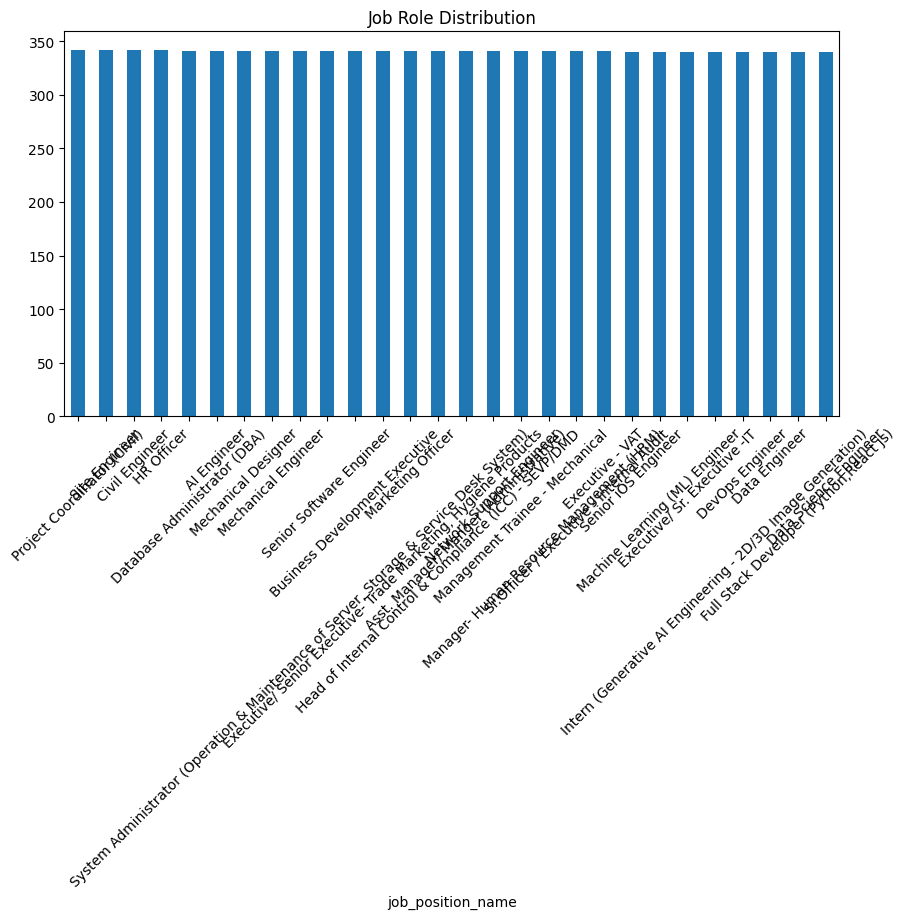

In [8]:
# visualizing distribution of job roles to check class imbalance
plt.figure(figsize=(10,5))
df['job_position_name'].value_counts().plot(kind='bar')
plt.title("Job Role Distribution")
plt.xticks(rotation=45)
plt.show()

In [9]:
# basic text preprocessing to normalize input text for vectorization
# removing numbers and punctuation while keeping meaningful keywords
# aggressive cleaning is avoided to preserve important skill tokens
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove very short words
    text = " ".join([word for word in text.split() if len(word) > 2])
    return text

In [10]:
# combining relevant text fields to create a unified input feature
# responsibilities and skills are used as they contain strongest signal for classification
df['combined'] = (
    df['skills'].fillna('') + " " +
    df['responsibilities'].fillna('') + " " +
    df['major_field_of_studies'].fillna('') + " " +
    df['positions'].fillna('')
)

In [11]:
def simplify_role(role):
    role = role.lower()
    if 'engineer' in role:
        return 'Engineer'
    elif 'hr' in role:
        return 'HR'
    elif 'database' in role:
        return 'Database'
    else:
        return 'Other'

df['job_position_name'] = df['job_position_name'].apply(simplify_role)

In [12]:
df = df[df['job_position_name'] != 'Other']

In [13]:
df['Resume'] = df['combined'].apply(clean_text)

In [14]:
# removing duplicate resumes to prevent data leakage between train and test sets
df = df.drop_duplicates(subset='Resume')

In [15]:
# selecting top job roles to reduce class complexity and improve model performance
top_roles = df['job_position_name'].value_counts().head(4).index
df = df[df['job_position_name'].isin(top_roles)]

In [16]:
# stratified split ensures equal representation of classes in train and test sets
X = df['Resume']
y = df['job_position_name']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# pipeline combines TF-IDF vectorization and logistic regression into a single workflow
# TF-IDF converts text into numerical features while also normalizing values
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
    stop_words='english',
    max_features=2000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7,
    sublinear_tf=True
)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

Hyperparameter Tuning

In [18]:
# hyperparameter tuning using cross-validation to find optimal regularization strength
param_grid = {
    'clf__C': [0.1, 1, 10]
}
grid = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.7,
                                                        max_features=2000,
                                                        min_df=5,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=-1, param_grid={'clf__C': [0.1, 1, 10]})

In [19]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'clf__C': 0.1}


In [20]:
y_pred = grid.predict(X_test)

In [21]:
# evaluating model performance using accuracy and detailed classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    Database       1.00      1.00      1.00        68
    Engineer       1.00      1.00      1.00       818
          HR       1.00      1.00      1.00       137

    accuracy                           1.00      1023
   macro avg       1.00      1.00      1.00      1023
weighted avg       1.00      1.00      1.00      1023



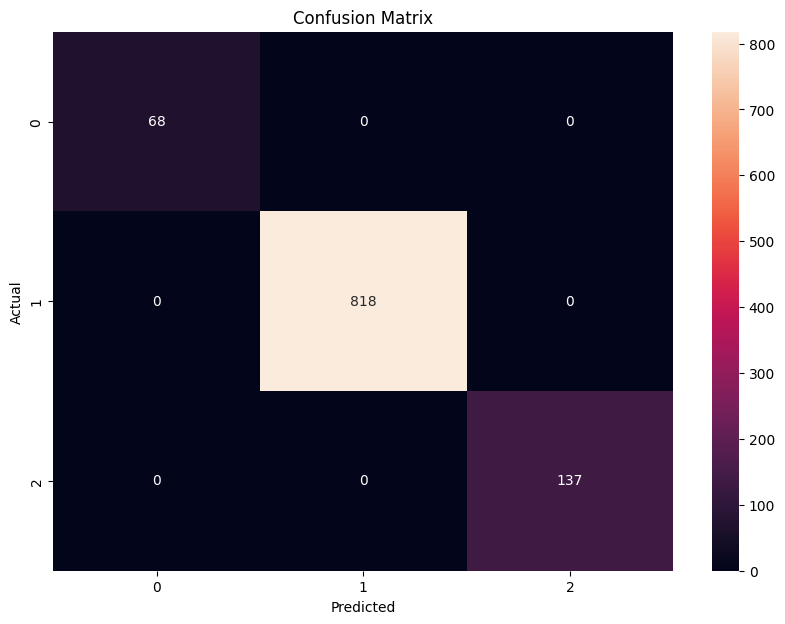

In [22]:
# confusion matrix helps visualize correct vs incorrect predictions per class
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
import os
os.makedirs('model', exist_ok=True)

In [24]:
with open('model/logistic_model.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)

In [25]:
from google.colab import files
files.download('model/logistic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import pickle
with open('model/logistic_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [27]:
# taking user input and predicting job role using trained model
# input should be skill-based text similar to training data
user_input = input("Enter resume skills: ")
print(model.predict([user_input]))

Enter resume skills: python machine learning data analysis
['Engineer']
